# Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
np.random.seed(32)

# Introduction

## Machine Learning
- The process of learning from experience (Data -> Experience)
- Mathematically, finding a function which takes features to outcome
- Based on outcome: Numeric -> Regression, Discrete -> Classification
- Classification Problem Definition:

Given set of features $X = (x_1, x_2)$ and outcome $y \in \{0,1\}$, need to find a function $f$ such that $$f(X) = y$$

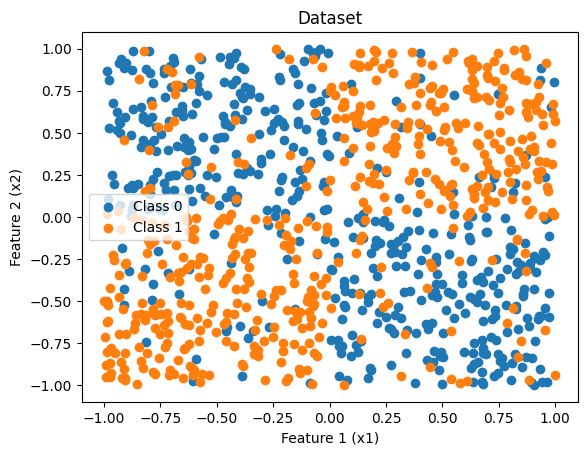

In [2]:
# Step 1: Generate dataset
def xor_2d(n_samples=8000, noise=0.15):
    X = np.random.uniform(-1, 1, (n_samples, 2))
    
    # XOR structure
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    
    # add label noise
    flip = np.random.rand(n_samples) < noise
    y[flip] = 1 - y[flip]
    
    return X, y

X, y = xor_2d(n_samples=1000, noise=0.15)
X = pd.DataFrame(X, columns=["x1", "x2"])
y = pd.Series(y)

# Step 2: Plot
plt.scatter(X.loc[y == 0, 'x1'], X.loc[y == 0, 'x2'], label="Class 0")
plt.scatter(X.loc[y == 1, 'x1'], X.loc[y == 1, 'x2'], label="Class 1")
plt.xlabel("Feature 1 (x1)")
plt.ylabel("Feature 2 (x2)")
plt.title("Dataset")
plt.legend()
plt.show()

## Decision Tree

- Machine learning has variety of models:
    - Logistic Regression
    - Support Vector Machine
    - Neural Networks
    - Decision Tree
    - so on
- A ML model involves two things: 
    - Class of possible functions
    - Search process to efficiently find correct function from the set
- Decision Tree
    - Class of functions: Sequence of if-else tests
    $$\text{TEST 1: IF } condition1 \text{ THEN } \text{test2} \text{ ELSE } \text{test3} \\ \text{TEST 2: IF } condition2 \text{ THEN } 0 \text{ ELSE } 1 \\ \text{TEST 3: IF } condition3 \text{ THEN } 0 \text{ ELSE } 1  $$
    - Search Process:
        - Adds tests that improve the preditions
        - Mathematically, works to reduce imformation entropy

In [3]:
# Split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 2)
X_test shape: (200, 2)


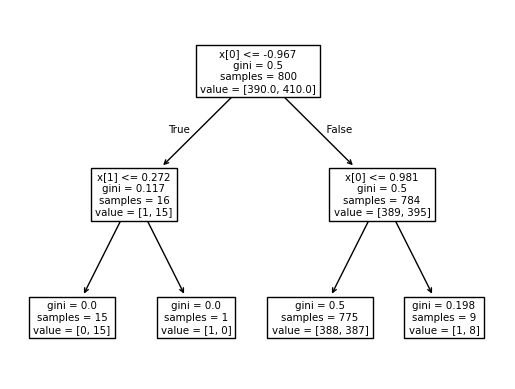

In [4]:
# Create decision-tree classifier
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)

# Show tree
if model.__class__.__name__ == "DecisionTreeClassifier":
    from sklearn.tree import plot_tree
    plot_tree(model)
    print()

## Problem
- Error
    - The difference between predicted and actual outcomes
    - For classification, we look at accuracy i.e. number of times model was correct
    $$E = \Sigma 1(c_{actual} == c_{predicted})$$

Error can have 3 reasons:
1. Noise (Irreducible error)
2. Wrong model (Bias)
3. Inability to generalize (Variance)


### Bias
- High Bias -> Class of functions does not contain function to learn

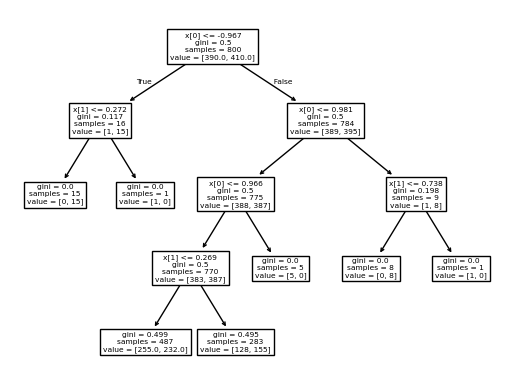

In [5]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Show tree
if model.__class__.__name__ == "DecisionTreeClassifier":
    from sklearn.tree import plot_tree
    plot_tree(model)
    print()

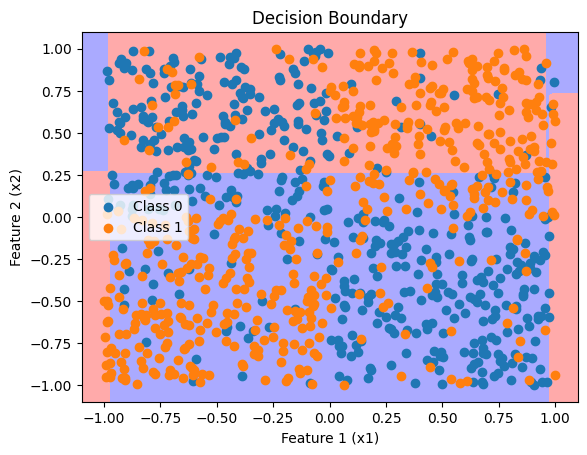

In [6]:
# Plot the decision boundary
from matplotlib.colors import ListedColormap
def plot_decision_boundary(model, X, y):
    x_min, x_max = X['x1'].min() - 0.1, X['x1'].max() + 0.1
    y_min, y_max = X['x2'].min() - 0.1, X['x2'].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    X_space = pd.DataFrame({'x1': xx.ravel(), 'x2': yy.ravel()})
    Z = model.predict(X_space)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=ListedColormap(['#AAAAFF', '#FFAAAA']))
    plt.scatter(X.loc[y == 0, 'x1'], X.loc[y == 0, 'x2'], label="Class 0")
    plt.scatter(X.loc[y == 1, 'x1'], X.loc[y == 1, 'x2'], label="Class 1")
    plt.xlabel("Feature 1 (x1)")
    plt.ylabel("Feature 2 (x2)")
    plt.title("Decision Boundary")
    plt.legend()
    plt.show()

plot_decision_boundary(model, X, y)

In [7]:
# Evaluate model, both on training and test sets
from sklearn.metrics import accuracy_score

print("Accuracy on training set:", accuracy_score(y_train, model.predict(X_train)))
print("Accuracy on test set:", accuracy_score(y_test, model.predict(X_test)))

Accuracy on training set: 0.55
Accuracy on test set: 0.49


### Variance
- High Variance -> Memorizes training data and cannot generalize

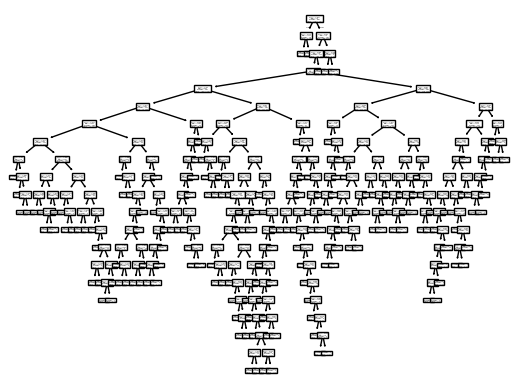

In [8]:
model = DecisionTreeClassifier(max_depth=20, random_state=42)
model.fit(X_train, y_train)

# Show tree
if model.__class__.__name__ == "DecisionTreeClassifier":
    from sklearn.tree import plot_tree
    plot_tree(model)
    print()

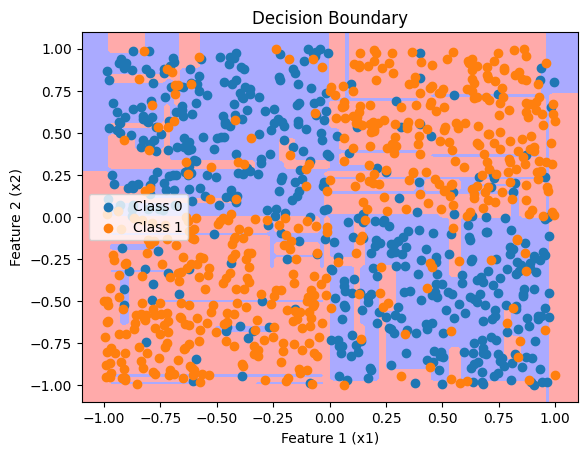

In [9]:
plot_decision_boundary(model, X, y)

In [10]:
print("Accuracy on training set:", accuracy_score(y_train, model.predict(X_train)))
print("Accuracy on test set:", accuracy_score(y_test, model.predict(X_test)))

Accuracy on training set: 0.9975
Accuracy on test set: 0.735


## Problem Statement

Goal: Find a model with low bias and low variance
Idea:
- A single model can be off with prediction, but a collection of models can do better
- Basically, A single model can have either high bias (Can't learn) or high variance (Can't generalize)
- If multiple model are combined together, it will reduce bias or variance
- Such a model is called Ensemble model

# Approach

There are two techiques: Bagging and Boosting

Both of them involves training multiple models but they differ with each other in terms of how they are trained and combined to make the prediction.

## Bagging
Idea: Individually each model learns an ascept of data but when combined leads to superior understanding
- Create $k$ copies of dataset $D$ by sampling with replacement
$$\{D_1, D_2, ..., D_k\}$$
- Some points repeat, some point are missed -> More noise
- For each these copies $D_i$, train a new model $f_i$
- Finally, use all the trained models to vote the final prediction
$$y = majority\{f_1(x), f_2(x), ..., f_n(x)\}$$


### Why do this work?
- Each model is trained on noisy data
- Individual model would have higher error rate due to high variance
- Combined model will have reduced variance -> Lower error

In [11]:
from sklearn.base import BaseEstimator, clone

class BaggingTreeClassifier(BaseEstimator):
    def __init__(self, num_estimators=10, base_estimator=DecisionTreeClassifier(max_depth=20, random_state=np.random.randint(0, 100))):
        self.base_estimator = base_estimator
        self.num_estimators = num_estimators
        self.models = []
        self.train_sets = []

    def sample_with_replacement(self, X, y):
        indices = np.random.choice(X.shape[0], X.shape[0], replace=True)
        return X.iloc[indices], y.iloc[indices]

    def create_copies(self, X, y):
        return [self.sample_with_replacement(X, y) for _ in range(self.num_estimators)]

    def fit(self, X, y):
        self.train_sets = self.create_copies(X, y)
        self.models = [clone(self.base_estimator).fit(X_train, y_train) for X_train, y_train in self.train_sets]
        return self

    def predict(self, X):
        predictions = [model.predict(X) for model in self.models]
        return np.round(np.mean(predictions, axis=0))


# Train model on each copy of training set
model = BaggingTreeClassifier(num_estimators=100)

training_sets = model.create_copies(X_train, y_train)
print("Number of training sets:", len(training_sets))
print("Training sets shape:", training_sets[0][0].shape)

Number of training sets: 100
Training sets shape: (800, 2)


Accuracy scores on test set:


count    100.000000
mean       0.741000
std        0.029949
min        0.655000
25%        0.720000
50%        0.742500
75%        0.760000
max        0.800000
dtype: float64

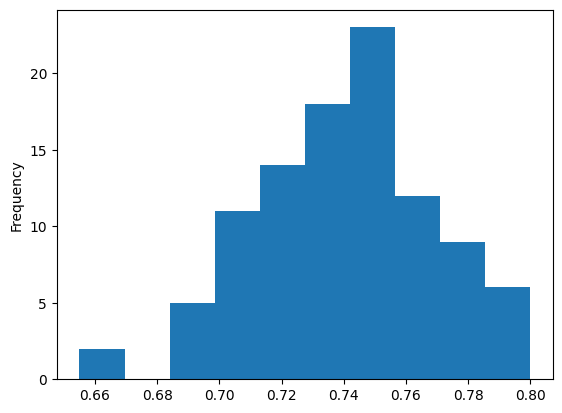

In [12]:
# Evaluate model on test set
model.fit(X_train, y_train)

accuracy_scores = pd.Series([accuracy_score(y_test, single_model.predict(X_test)) for single_model in model.models])
print("Accuracy scores on test set:")
accuracy_scores.plot(kind="hist")
accuracy_scores.describe()

In [13]:
print("Accuracy on training set:", accuracy_score(y_train, model.predict(X_train)))
print("Accuracy on test set:", accuracy_score(y_test, model.predict(X_test)))

Accuracy on training set: 1.0
Accuracy on test set: 0.82


Accuracy on training set: 1.0
Accuracy on test set: 0.82


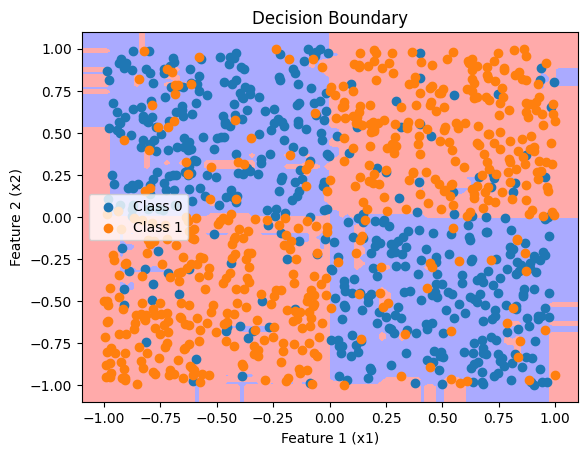

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Accuracy on training set:", accuracy_score(y_train, model.predict(X_train)))
print("Accuracy on test set:", accuracy_score(y_test, model.predict(X_test)))

plot_decision_boundary(model, X, y)

## Boosting
Idea: Each model learns from each other's mistakes, so when combined, leads to correct prediction

- Train a model $f_0$ on the original dataset and repeat following steps
- Calculate the error $E$ from the model $f_i$
- Calculate the model important $\alpha_i$ from error
$$\alpha_i = \log(\frac{1-E}{E})$$
- For each datapoint $x_k$, calculate the weight $w_{k,i+1}$ (Assuming $y \in \{-1, +1\}$)
$$w_{k,i+1} = w_{k,i} * e^{-\alpha_i*y_k*y_{pred}}$$
- Use the mistakes to train a new model $f_{i+1}$ using weights for each datapoints
- Higher the weight, more the model with try to learn the datapoint
- Use all the model with importance to perform the prediction
$$y = sign(\Sigma \alpha_i f_i(x))$$

### Why does this work?
- Each model learns from previous model's mistake
- Individual model again have error higher rate -> Have high bias
- When combined, they lead to lower bias

Accuracy scores on test set:


count    3.000000
mean     0.561667
std      0.264874
min      0.340000
25%      0.415000
50%      0.490000
75%      0.672500
max      0.855000
dtype: float64

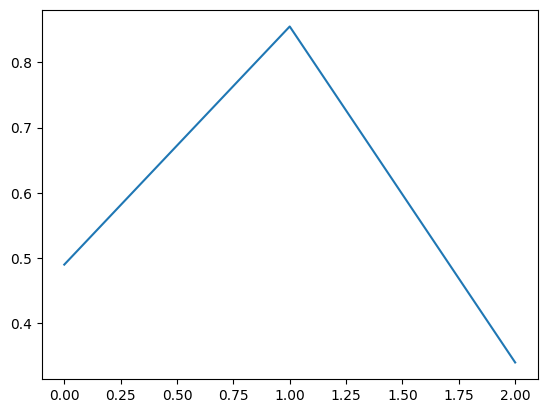

In [15]:
class BoostingTreeClassifier(BaseEstimator):
    def __init__(self, num_estimators=10, base_estimator=DecisionTreeClassifier(max_depth=4, random_state=np.random.randint(0, 100))):
        self.base_estimator = base_estimator
        self.num_estimators = num_estimators
        self.models = []
        self.alphas = []

    def fit(self, X, y):
        weight = 1/X.shape[0]
        for _ in range(self.num_estimators):
            model = clone(self.base_estimator).fit(X, y, sample_weight=weight)
            self.models.append(model)
            y_pred = model.predict(X)
            error = np.mean(y != y_pred)
            alpha = np.log((1-error)/error)
            self.alphas.append(alpha)
            weight = weight * np.exp(-1 * alpha * (2 * y - 1) * (2 * y_pred - 1))
        return self

    def predict(self, X):
        predictions = np.zeros(X.shape[0])
        for i, model in enumerate(self.models):
            predictions += self.alphas[i] * model.predict(X)
        return np.round((np.sign(predictions) + 1) / 2)
    
model = BoostingTreeClassifier(num_estimators=3)
model.fit(X_train, y_train)

accuracy_scores = pd.Series([accuracy_score(y_test, single_model.predict(X_test)) for single_model in model.models])
print("Accuracy scores on test set:")
accuracy_scores.plot()
accuracy_scores.describe()


In [16]:
print("Accuracy on training set:", accuracy_score(y_train, model.predict(X_train)))
print("Accuracy on test set:", accuracy_score(y_test, model.predict(X_test)))

Accuracy on training set: 0.82625
Accuracy on test set: 0.82


Accuracy on training set: 0.8775
Accuracy on test set: 0.84


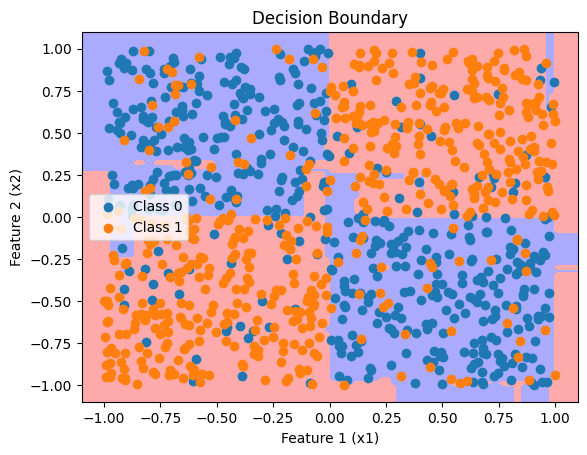

In [17]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Accuracy on training set:", accuracy_score(y_train, model.predict(X_train)))
print("Accuracy on test set:", accuracy_score(y_test, model.predict(X_test)))

plot_decision_boundary(model, X, y)